In [5]:
# pip install torch torchtext transformers datasets scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   -- ------------------------------------- 8.1/113.8 MB 40.5 MB/s eta 0:00:03
   ------- -------------------------------- 22.5/113.8 MB 54.1 MB/s eta 0:00:02
   ------------- -------------------------- 38.0/113.8 MB 60.0 MB/s eta 0:00:02
   ------------------ --------------------- 54.0/113.8 MB 63.6 MB/s eta 0:00:01
   ------------------------- -------------- 71.8/113.8 MB 67.6 MB/s eta 0:00:01
   ------------------------------- -------- 89.1/113.8 MB 70.5 MB/s eta 0:00:01
   ------------------------------------ -- 106.4/113.8 MB 71.9 MB/s eta 0:00:01
   --------------------------------------  113.5/113.8 MB 72.2 MB/s eta 0:00:01
   ---------------------------------------- 113.8/113.8 MB 65.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 61.0 MB/s 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached torchtext-0.6.0-py3-none-any.whl.metadata (6.3 kB)
Using cached torchtext-0.6.0-py3-none-any.whl (64 kB)
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 10.4/10.4 MB 51.2 MB/s  0:00:00
   ---------------------------------------- 0.0/596.3 kB ? eta -:--:--
   ---------------------------------------- 596.3/596.3 kB 35.1 MB/s  0:00:00
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ---------------------------------------- 3.6/3.6 MB 48.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 53.8 MB/s  0:00:00
   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   -------------------- ------------------- 14.4/28.2 MB 69.9 MB/s eta 0:00:01
   ---------------------------------------  28.0/28.2 MB 68.8 MB/s eta 0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
import importlib
import pandas as pd
import seaborn
from IPython.display import Image
import matplotlib.pyplot as plt

import Transformer as tnsf
import detection_model as ad

importlib.reload(ad)
importlib.reload(tnsf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
torch.cuda.is_available()

False

In [3]:
pd.options.display.width = 400
pd.options.display.max_colwidth = 400

## Data Preproccesing

In [23]:
# Original Codes (process 12 mio rows of log data)

# Parse from file
# Input log file name
log_file  = 'HDFS.log'
log_source  = 'HDFS'
algorithm = 'Spell'
ad.parse(log_source, log_file, algorithm)

Processed 100.0% of log lines.


KeyboardInterrupt: 

In [22]:
# 2k rows of log data

log_file  = 'HDFS_2k.log'
log_source  = 'HDFS'
algorithm = 'Spell'
ad.parse(log_source, log_file, algorithm)

Processed 100.0% of log lines.
Parsing done. [Time taken: 0:00:00.299649]


In [10]:
# Original raw logs
N = 10
with open("Dataset/HDFS/HDFS.log") as file:
    for i in range(N): print(next(file).strip())

081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating
081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating
081109 204132 26 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.43.115:50010 is added to blk_3050920587428079149 size 67108864
081109 204324 34 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.203.80:50010 is added to blk_7888946331804732825 size 67108864
081109 204453 34 INFO dfs.FSNamesystem: BLOCK*

In [4]:
# Identified log patterns
log_structured = pd.read_csv("Spell_result/" +  "HDFS_templates.csv") 
log_structured

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


## Log sequences are divided based on each unique block_id
## Block_ids represent different sessions of log events related to each other

In [5]:
# Log sequences 
# Rows are divided based on each unique block_id
# We create a new row when there is a new block_id in the structured event logs
N = 10
with open("Dataset/HDFS/hdfs_train") as file:  # the a opens it in append mode
    for i in range(N):
        print(next(file).strip())

32 1 1 2 1 3 4 3 4 3 4 5 5 5 23 23 23 13 13 13
1 2 1 1 3 4 3 4 3 4 5 5 5 23 23 23 13 13 13
2 1 1 1 3 4 5 3 4 5 3 4 5 23 23 23 13 13 13
1 1 1 2 3 4 3 4 5 3 4 5 5
2 1 1 1 5 5 5 3 4 3 4 3 4 23 23 23 13 13 13
1 2 1 1 3 4 3 4 3 4 5 5 5 23 23 23 13 13 13
1 1 1 2 3 4 3 4 3 4 5 5 5 23 23 23 13 13 13
1 1 1 2 3 4 3 4 3 4 5 5 5
1 1 1 2 3 4 3 4 3 4 5 5 5
2 1 1 1 5 5 5 3 4 3 4 3 4 25 25 6 9 9 23 23 23 13 13 13


## Model Training

In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())

False
0


In [7]:
# Traning with 4 encoders and decoders, 4 attention heads, and dimension of 512
# Hyperparameters are smaller than those used in NLP since there is a smaller range of combinations
# NLP involves the whole vocabulary of a language, while log detection has a smaller finite number of logs
model = tnsf.train(N=4, d_model=512, d_ff=2048, h=4, dropout=0.1)

4 512 2048 4 0.1


C:\Users\miqba\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Epoch Step: 1 Loss: 4.256456 Tokens per Sec: 362.491547
Epoch Step: 1 Loss: 0.378075 Tokens per Sec: 735.581238
tensor(0.3781)
Epoch Step: 1 Loss: 0.602379 Tokens per Sec: 426.282318
Epoch Step: 1 Loss: 0.199121 Tokens per Sec: 733.550659
tensor(0.1991)
Epoch Step: 1 Loss: 0.459644 Tokens per Sec: 428.487122
Epoch Step: 1 Loss: 0.287526 Tokens per Sec: 765.505676
tensor(0.2875)
Epoch Step: 1 Loss: 1.725279 Tokens per Sec: 445.312683
Epoch Step: 1 Loss: 0.206044 Tokens per Sec: 710.117493
tensor(0.2060)
Epoch Step: 1 Loss: 0.289891 Tokens per Sec: 429.375366
Epoch Step: 1 Loss: 0.093124 Tokens per Sec: 730.325562
tensor(0.0931)
Epoch Step: 1 Loss: 0.166660 Tokens per Sec: 445.868286
Epoch Step: 1 Loss: 0.132666 Tokens per Sec: 714.612000
tensor(0.1327)
Epoch Step: 1 Loss: 0.381436 Tokens per Sec: 421.028320
Epoch Step: 1 Loss: 0.135309 Tokens per Sec: 734.311707
tensor(0.1353)
Epoch Step: 1 Loss: 0.244726 Tokens per Sec: 440.435608
Epoch Step: 1 Loss: 0.151137 Tokens per Sec: 741.273193

## Model evaluation

In [8]:
tnsf.test(model)

553241
553241
16838
16838
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
15

* Accuracy = (TP + TN) / (TP + FP + FN + TN)
* Precision = TP / (TP + FP)  -> Of all the logs that were predicted as anomalies, how many were actually anomalies?
* Recall = TP / (TP + FN)  -> Of all the actual anomalies, how many were correctly identified?
* F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

## Visualization

In [29]:
#We create log sequences with 10 log keys
WINDOW_SIZE = 10

In [44]:
model = torch.load("Model/centralized_models.pt", weights_only=False)
model.eval()

# Parameter
WINDOW_SIZE = 10

# Log sequence
# 5 5 22 5 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21 20
# seq = [5, 5, 22, 5, 11, 9, 11, 9, 11, 9, 26, 26, 26, 23, 23, 23, 21, 21, 21, 20]
seq = [22, 5, 5, 5, 26, 26, 26, 11, 9, 11, 9, 11, 9, 3, 3, 4, 3, 4, 3, 3]

#Input log sequence
src = seq[:WINDOW_SIZE]
#Output log sequence
tgt = seq[WINDOW_SIZE:]
# src = [5, 5, 22, 5, 11, 9, 11, 9, 11, 9]
# tgt = [26, 26, 26, 23, 23, 23, 21, 21, 21, 20]

# Input log sequence
src = seq[:WINDOW_SIZE]
# Expected log sequence
tgt = seq[WINDOW_SIZE:]

src_mask = Variable(torch.ones(1, 1, WINDOW_SIZE+1) )

t1 = torch.from_numpy(np.zeros((1,WINDOW_SIZE+1),dtype=int))
t1[0][1:WINDOW_SIZE+1] = torch.tensor(src, dtype=torch.float).to(device)
t1[0][0]=1

t2 = torch.from_numpy(np.zeros((1,WINDOW_SIZE+1),dtype=int))
t2[0][0:len(tgt)] = torch.tensor(tgt, dtype=torch.float).to(device)

tgt = Variable(t2, requires_grad=False)
src = Variable(t1, requires_grad=False)

# Predicted log sequence
tgt_pred = tnsf.greedy_decode(model, src, src_mask, tgt, WINDOW_SIZE+1, 1, False, 9) 

In [45]:
src= src[0][1:]
tgt_pred = np.reshape(tgt_pred.numpy(), (10,))
src = list(np.reshape(src.numpy(), (10,)))

In [46]:
def draw(data, x, y, ax, cbar_ax):
    seaborn.heatmap(data, xticklabels=x, square=True, yticklabels=y, vmin=0.0, vmax=1.0,annot=False, cbar_ax=cbar_ax,cbar=True, ax=ax)

### Horizontal axis represents the logs the model is predicting. 
### Vertical axis are the logs that the model is focusing on, applying attention, to predict next log on horizontal axis.

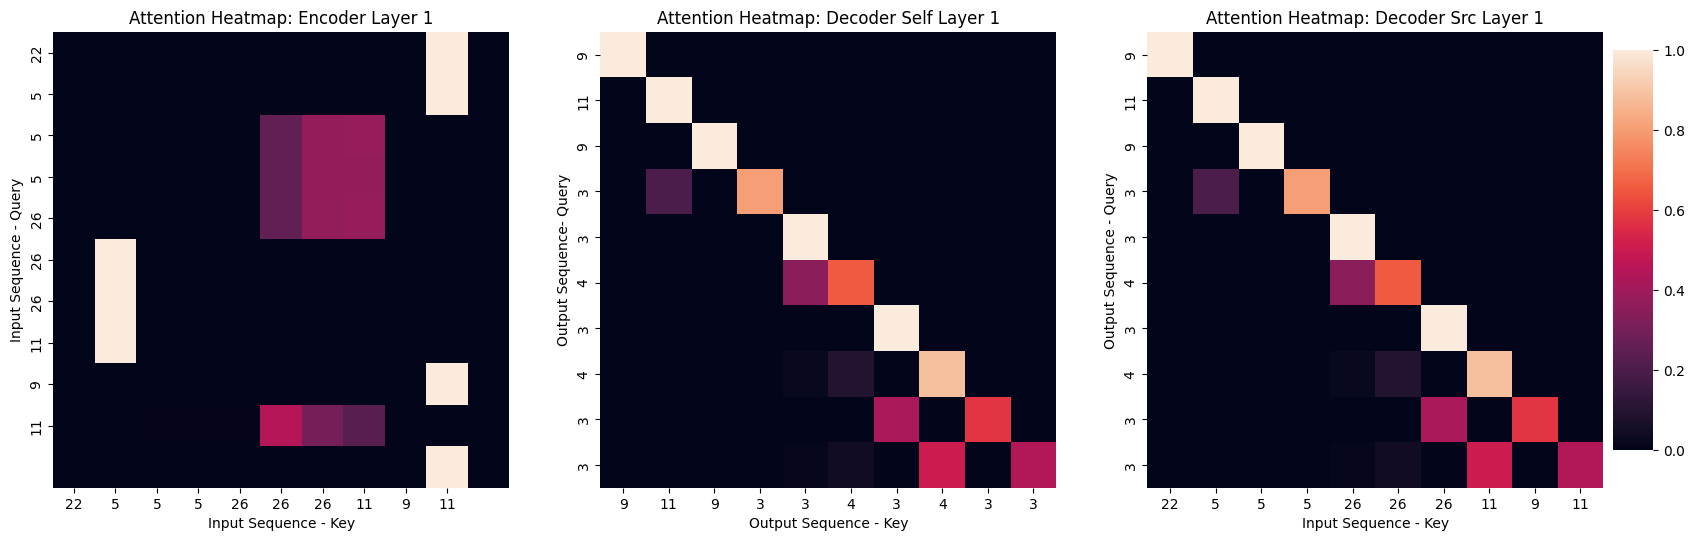

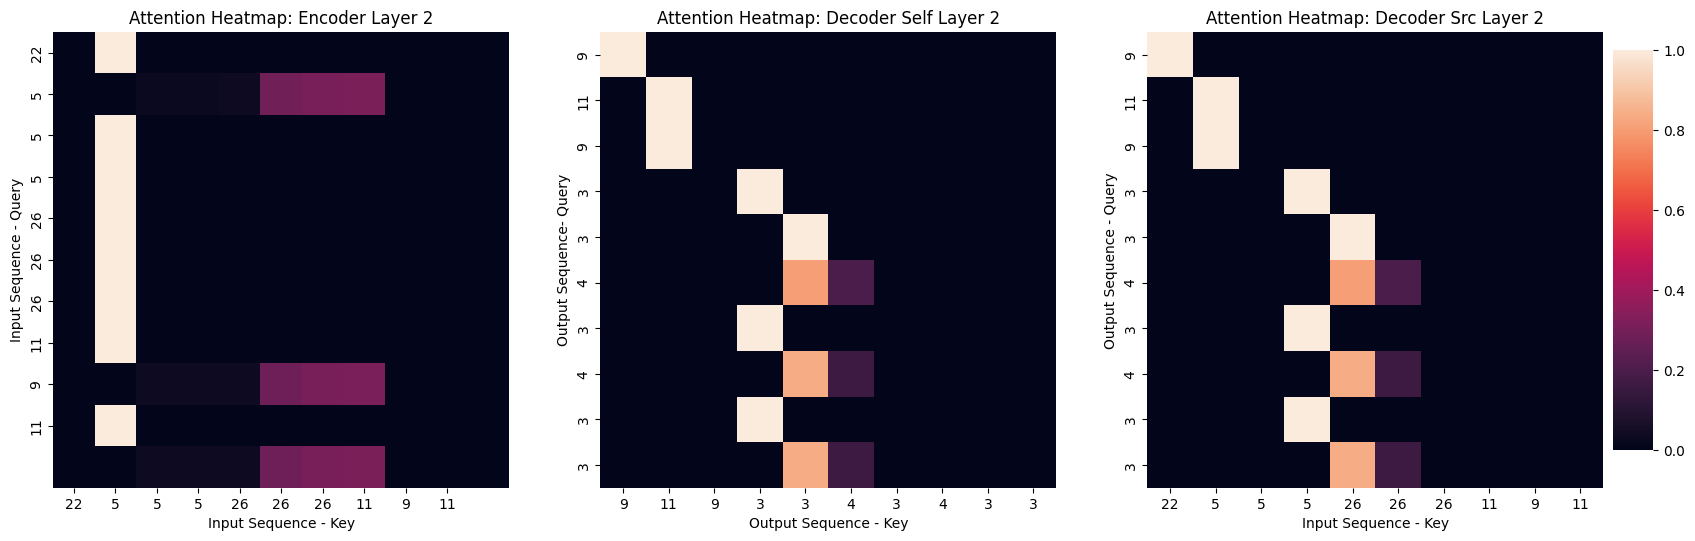

In [47]:
#Attention heatmap
r = 0
for layer in range(2):
    fig, axs = plt.subplots(1,3, figsize=(20, 20))
    cbar_ax = fig.add_axes([.905, .4, .02, .2])
    for h in range(1):
        draw(model.encoder.layers[layer].self_attn.attn[0, h].data, src, src if h ==0 else [], ax=axs[r], cbar_ax=cbar_ax )
        axs[r].set_xlabel('Input Sequence - Key')
        axs[r].set_ylabel('Input Sequence - Query')
        axs[r].set_title("Attention Heatmap: Encoder Layer " + str(layer+1))
        draw(model.decoder.layers[layer].self_attn.attn[0, h].data[:len(tgt_pred), :len(tgt_pred)], tgt_pred, tgt_pred if h ==0 else [], ax=axs[r+1], cbar_ax=cbar_ax )
        axs[r + 1].set_xlabel('Output Sequence - Key')
        axs[r + 1].set_ylabel('Output Sequence- Query')        
        axs[r + 1].set_title("Attention Heatmap: Decoder Self Layer " + str(layer+1))
        draw(model.decoder.layers[layer].self_attn.attn[0, h].data[:len(tgt_pred), :len(src)], src, tgt_pred if h ==0 else [], ax=axs[r+2], cbar_ax=cbar_ax )
        axs[r + 2].set_xlabel('Input Sequence - Key')
        axs[r + 2].set_ylabel('Output Sequence - Query')
        axs[r + 2].set_title("Attention Heatmap: Decoder Src Layer " + str(layer+1))
        
    plt.show()

The heatmap is generated for:   
*  Encoder self-attention (input sequence to input sequence).
*  Decoder self-attention (output sequence to output sequence).
*  Decoder source attention (input sequence to output sequence).

|  | <font size="4">Positive</font>  | <font size="4">Negative</font> |
| --- | --- | --- |
| <font size="4">**True**</font> | <font size="4">There is a problem and alarm turns on </font>| <font size="4">There is no problem and no alarm </font>|
| <font size="4">**False**</font> | <font size="4">There is no problem but alarm turns on</font> | <font size="4">There is a problem but no alarm</font> |

## Normal behavior log sequence

In [ ]:
# 22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 4 3 3 3 4 3 3 4 23 23 23 21 21 21 
# Log sequence
seq = [22, 5, 5, 5, 26, 26, 26, 11, 9, 11, 9, 11, 9, 3, 3, 4, 3, 4, 3, 3]

# Input log sequence
src = seq[:WINDOW_SIZE]
# src = [22, 5, 5, 5, 26, 26, 26, 11, 9, 11]

# Output log sequence
tgt = seq[WINDOW_SIZE:]
# tgt = [9, 11, 9, 3, 3, 4, 3, 4, 3, 3]

t1 = torch.from_numpy(np.zeros((1,WINDOW_SIZE+1),dtype=int))
t1[0][1:WINDOW_SIZE+1] = torch.tensor(src, dtype=torch.float).to(device)
t1[0][0]=1

t2 = torch.from_numpy(np.zeros((1,WINDOW_SIZE+1),dtype=int))
t2[0][0:len(tgt)] = torch.tensor(tgt, dtype=torch.float).to(device)

tgt = Variable(t2, requires_grad=False)
src = Variable(t1, requires_grad=False)

# Predict log sequence
tgt_pred = tnsf.greedy_decode(model, src, src_mask, tgt, WINDOW_SIZE+1, 1, True, 9) 

if -1 in tgt_pred: print("Abnormal log sequence: false positive")
else: print("Normal log sequence: true negative\n", tgt_pred)

Incoming log: tensor(9)
Candidate logs: tensor([25, 18, 23,  3,  2,  4, 11, 26,  9]) 

Incoming log: tensor(11)
Candidate logs: tensor([25, 14, 18,  3, 26,  2,  9,  4, 11]) 

Incoming log: tensor(9)
Candidate logs: tensor([ 1, 18, 25, 11, 26,  2,  4,  3,  9]) 

Incoming log: tensor(3)
Candidate logs: tensor([19, 28, 18, 23,  9, 26,  2,  3,  4]) 

Incoming log: tensor(3)
Candidate logs: tensor([25, 18, 11, 23, 26,  9,  2,  3,  4]) 

Incoming log: tensor(4)
Candidate logs: tensor([25, 18, 11, 23, 26,  9,  2,  3,  4]) 

Incoming log: tensor(3)
Candidate logs: tensor([25, 13, 18,  9, 21, 26,  2,  4,  3]) 

Incoming log: tensor(4)
Candidate logs: tensor([18, 21, 11, 23, 26,  9,  2,  3,  4]) 

Incoming log: tensor(3)
Candidate logs: tensor([28, 13, 18,  9, 21, 26,  2,  4,  3]) 

Incoming log: tensor(3)
Candidate logs: tensor([18, 21, 11, 23, 26,  9,  2,  3,  4]) 

Normal log sequence: true negative
 tensor([[ 9, 11,  9,  3,  3,  4,  3,  4,  3,  3]])


## Abnormal behavior log sequence

In [ ]:
#Log sequence

seq = [ 5, 22, 11, 9, 11, 9, 11, 9, 26, 26, 26, 23, 23, 23, 21, 21, 21, 20, 20, 20]
#Input log sequence

src = seq[:WINDOW_SIZE]
# src = [5, 22, 11, 9, 11, 9, 11, 9, 26, 26]

#Output log sequence
tgt = seq[WINDOW_SIZE:]
# tgt = [26, 23, 23, 23, 21, 21, 21, 20, 20, 20]

t1 = torch.from_numpy(np.zeros((1,WINDOW_SIZE+1),dtype=int))
t1[0][0]=1
t1[0][1:WINDOW_SIZE+1] = torch.tensor(src, dtype=torch.float).to(device)


src = Variable(t1, requires_grad=False)
t2[0][0:len(tgt)] = torch.tensor(tgt, dtype=torch.float).to(device)
tgt = Variable(t2, requires_grad=False)

#Predict log sequence
tgt_pred = tnsf.greedy_decode(model, src, src_mask, tgt, WINDOW_SIZE+1, 1, True, 9) 

#If -1 in predicted sequence, anomaly detected
if -1 in tgt_pred: 
    print("Abnormal log sequence: true positive\n", tgt_pred)
#Otherwise, no anomaly was detected
else: 
    print("Normal log sequence: false negative")

Incoming log: tensor(26)
Candidate logs: tensor([25, 18, 23,  3,  2,  4, 11, 26,  9]) 

Incoming log: tensor(23)
Candidate logs: tensor([25, 18, 23,  3,  2,  4, 11, 26,  9]) 

Incoming log: tensor(23)
Candidate logs: tensor([17,  2,  3, 11,  4, 21,  9, 26, 23]) 

Incoming log: tensor(23)
Candidate logs: tensor([28, 17,  2,  9,  4,  3, 26, 21, 23]) 

Incoming log: tensor(21)
Candidate logs: tensor([28, 17,  2,  9,  4,  3, 26, 21, 23]) 

Incoming log: tensor(21)
Candidate logs: tensor([28, 17,  2,  9,  4,  3, 26, 21, 23]) 

Incoming log: tensor(21)
Candidate logs: tensor([ 2,  0, 23,  9, 11,  3,  4, 26, 21]) 

Incoming log: tensor(20)
Candidate logs: tensor([ 2,  0, 23,  9, 11,  3,  4, 26, 21]) 

Abnormal log sequence: true positive
 tensor([[26, 23, 23, 23, 21, 21, 21, 20, -1]])


In [25]:
algorithm

'Spell'

## Find logs that caused anomaly

In [64]:
#Backtrack to logs that caused anomaly
ad.backtrace(tgt_pred, log_source, algorithm)

26 [*]BLOCK* NameSystem[*]addStoredBlock: blockMap updated:[*]is added to[*]size[*]
23 [*]BLOCK* NameSystem[*]delete:[*]is added to invalidSet of[*]
23 [*]BLOCK* NameSystem[*]delete:[*]is added to invalidSet of[*]
23 [*]BLOCK* NameSystem[*]delete:[*]is added to invalidSet of[*]
21 [*]Deleting block[*]file[*]
21 [*]Deleting block[*]file[*]
21 [*]Deleting block[*]file[*]
20 [*]Unexpected error trying to delete block[*]BlockInfo not found in volumeMap[*]


## Mapping between log key and event templates

In [65]:
#Mapping between log key and event template
log_structured = pd.read_csv("Spell_result/" +  "HDFS_templates.csv") 
log_structured

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]
